# Text associations

Associations between normalized reading times on the **text regions**
(distractor / critical / outside) and on the **answers & question** (A / B / C / D / question).

Data: `L1_model_ready_all_features.csv` (`READY_ALL_FEATURES_PATH`).

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_paths import READY_ALL_FEATURES_PATH

df = pd.read_csv(READY_ALL_FEATURES_PATH)
print(df.shape)
df.head()

(19436, 208)


,participant_id,TRIAL_INDEX,text_id_with_q,is_correct,area_dwell_proportion__answer_A,area_dwell_proportion__answer_B,area_dwell_proportion__answer_C,area_dwell_proportion__answer_D,area_dwell_proportion__question,first_encounter_avg_pupil_size_z__answer_A,...,TimeSinceOffset_pure_distance_furthest,TimeSinceOffset_pure_distance_closest,TimeSinceOffset_normalized_correct,TimeSinceOffset_normalized_wrong_mean,TimeSinceOffset_normalized_contrast,TimeSinceOffset_normalized_distance_furthest,TimeSinceOffset_normalized_distance_closest,ANSWER_PRESS_NUMBER,total_answering_RT,total_answering_RT_normalized
0,l42_2070,4,3_6_Ele_1_2,1,0.319310,0.213167,0.181306,0.257173,0.029044,0.798335,...,1734.0,251.0,593.000000,602.857143,-9.857143,163.000000,48.857143,1,7330,222.121212
1,l42_2070,5,3_6_Adv_2_2,1,0.244538,0.469212,0.170161,0.116089,0.000000,0.086368,...,1110.0,23.0,106.083333,261.925926,-155.842593,158.694444,153.116667,1,5650,141.250000
2,l42_2070,6,3_6_Ele_3_0,1,0.388110,0.148282,0.349458,0.079114,0.035036,-0.436190,...,2750.0,1584.0,324.500000,277.523810,46.976190,269.500000,179.928571,1,5562,135.658537
3,l42_2070,7,3_6_Adv_4_1,1,0.501591,0.178867,0.126353,0.147995,0.045194,0.590876,...,3599.0,1576.0,404.900000,219.950000,184.950000,359.900000,89.700000,1,4762,136.057143
4,l42_2070,8,3_6_Ele_5_0,1,0.241206,0.370537,0.153399,0.177466,0.057392,-1.167965,...,1748.0,287.0,123.000000,211.171296,-88.171296,264.625000,59.222222,1,4884,103.914894


In [2]:
# Build model-ready features per group (hunters / gatherers) from the processed
# per-group CSVs, saved next to the all-participants file with the group noted.
from src.data_paths import (
    HUNTERS_PROCESSED_PATH,
    GATHERERS_PROCESSED_PATH,
    L1_BASED_DATA_DIR,
)
from src.predictive_modeling.answer_correctness.model_data import save_all_features

GROUP_RAW_PATHS = {
    "hunters": HUNTERS_PROCESSED_PATH,
    "gatherers": GATHERERS_PROCESSED_PATH,
}
GROUP_FEATURE_PATHS = {
    name: L1_BASED_DATA_DIR / f"L1_model_ready_{name}_features.csv"
    for name in GROUP_RAW_PATHS
}

REBUILD = False  # set True to regenerate the per-group feature CSVs
group_dfs = {}
for name, raw_path in GROUP_RAW_PATHS.items():
    feat_path = GROUP_FEATURE_PATHS[name]
    if REBUILD or not feat_path.exists():
        save_all_features(pd.read_csv(raw_path), output_path=feat_path)
    group_dfs[name] = pd.read_csv(feat_path)
    print(name, group_dfs[name].shape)

hunters (9719, 208)
gatherers (9717, 208)


In [3]:
# Reusable cross-correlation heatmap: text regions (rows) vs. answers/question (cols)
REGIONS = ["distractor", "critical", "outside"]
ANSWERS = ["answer_A", "answer_B", "answer_C", "answer_D", "question"]


def region_answer_cross_corr(df, metric):
    """metric in {'RT', 'TFD'} -> 3x5 cross-correlation of normalized values."""
    region_cols = [f"{metric}_normalized_{r}" for r in REGIONS]
    answer_cols = [f"{metric}_normalized_{a}" for a in ANSWERS]
    corr = df[region_cols + answer_cols].corr().loc[region_cols, answer_cols]
    pretty = lambda c: c.replace(f"{metric}_normalized_", "").replace("answer_", "ans ")
    return corr.rename(index=pretty, columns=pretty)


def plot_cross_corr(cc, ax, title):
    im = ax.imshow(cc.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(cc.shape[1]))
    ax.set_xticklabels(cc.columns, rotation=45, ha="right")
    ax.set_yticks(range(cc.shape[0]))
    ax.set_yticklabels(cc.index)
    for i in range(cc.shape[0]):
        for j in range(cc.shape[1]):
            v = cc.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if abs(v) > 0.5 else "black", fontsize=9)
    ax.set_title(title)
    return im


def plot_group(df, group_label):
    """RT and TFD cross-correlation heatmaps side by side for one group."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric in zip(axes, ["RT", "TFD"]):
        cc = region_answer_cross_corr(df, metric)
        im = plot_cross_corr(cc, ax, f"{group_label} — normalized {metric}")
    fig.colorbar(im, ax=axes, label="Pearson r", fraction=0.025)
    fig.suptitle(f"{group_label}: text regions vs. answers/question", y=1.05)
    plt.show()

In [4]:
# Normalized reading-time columns: text regions (rows) vs. answers/question (cols)
text_region_cols = [
    "RT_normalized_distractor",
    "RT_normalized_critical",
    "RT_normalized_outside",
]
answer_cols = [
    "RT_normalized_answer_A",
    "RT_normalized_answer_B",
    "RT_normalized_answer_C",
    "RT_normalized_answer_D",
    "RT_normalized_question",
]

# Full pairwise correlation, then slice to the cross-block (regions x answers/question)
corr = df[text_region_cols + answer_cols].corr()
cross_corr = corr.loc[text_region_cols, answer_cols]

pretty = lambda c: c.replace("RT_normalized_", "").replace("answer_", "ans ").replace("_", " ")
cross_corr_display = cross_corr.rename(index=pretty, columns=pretty)
cross_corr_display.round(3)

,ans A,ans B,ans C,ans D,question
distractor,0.067,0.073,0.117,0.067,0.052
critical,0.126,0.132,0.127,0.125,0.068
outside,0.082,0.074,0.086,0.078,0.050


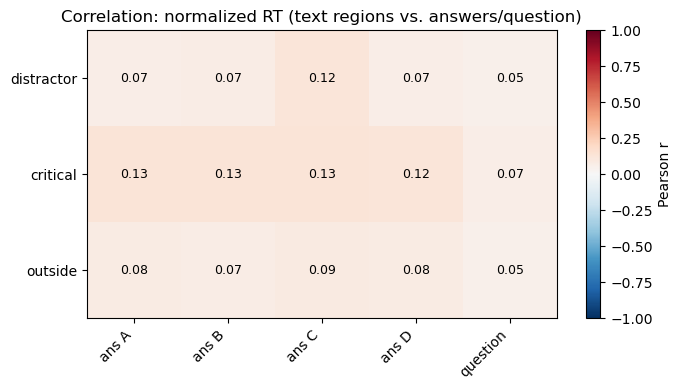

In [5]:
# Heatmap of the cross-correlation block
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(cross_corr_display.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(cross_corr_display.shape[1]))
ax.set_xticklabels(cross_corr_display.columns, rotation=45, ha="right")
ax.set_yticks(range(cross_corr_display.shape[0]))
ax.set_yticklabels(cross_corr_display.index)

for i in range(cross_corr_display.shape[0]):
    for j in range(cross_corr_display.shape[1]):
        v = cross_corr_display.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=9)

ax.set_title("Correlation: normalized RT (text regions vs. answers/question)")
fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

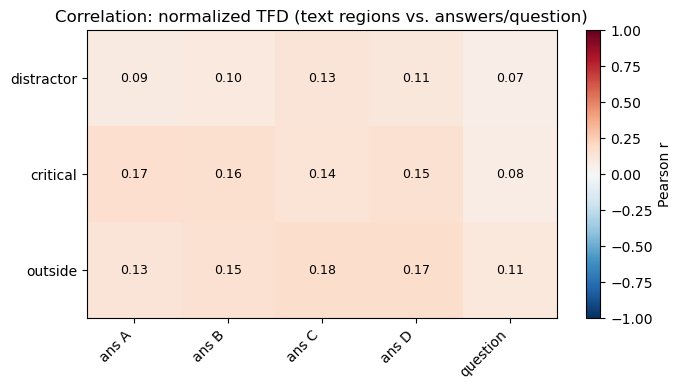

,ans A,ans B,ans C,ans D,question
distractor,0.092,0.095,0.127,0.112,0.066
critical,0.169,0.163,0.139,0.152,0.075
outside,0.132,0.151,0.177,0.173,0.108


In [6]:
# Same cross-correlation for TFD (total fixation duration), normalized
tfd_region_cols = [
    "TFD_normalized_distractor",
    "TFD_normalized_critical",
    "TFD_normalized_outside",
]
tfd_answer_cols = [
    "TFD_normalized_answer_A",
    "TFD_normalized_answer_B",
    "TFD_normalized_answer_C",
    "TFD_normalized_answer_D",
    "TFD_normalized_question",
]

tfd_corr = df[tfd_region_cols + tfd_answer_cols].corr()
tfd_cross_corr = tfd_corr.loc[tfd_region_cols, tfd_answer_cols]

tfd_pretty = lambda c: c.replace("TFD_normalized_", "").replace("answer_", "ans ").replace("_", " ")
tfd_cross_corr_display = tfd_cross_corr.rename(index=tfd_pretty, columns=tfd_pretty)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(tfd_cross_corr_display.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(tfd_cross_corr_display.shape[1]))
ax.set_xticklabels(tfd_cross_corr_display.columns, rotation=45, ha="right")
ax.set_yticks(range(tfd_cross_corr_display.shape[0]))
ax.set_yticklabels(tfd_cross_corr_display.index)

for i in range(tfd_cross_corr_display.shape[0]):
    for j in range(tfd_cross_corr_display.shape[1]):
        v = tfd_cross_corr_display.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=9)

ax.set_title("Correlation: normalized TFD (text regions vs. answers/question)")
fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

tfd_cross_corr_display.round(3)

## Per group: hunters vs. gatherers

Same cross-correlations (RT and TFD, normalized) computed separately for each group.

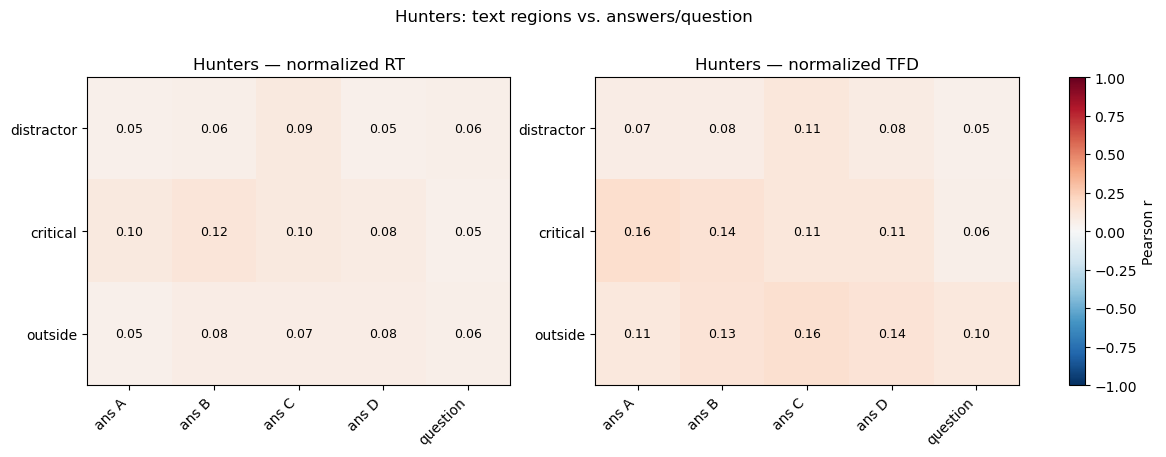

In [7]:
plot_group(group_dfs["hunters"], "Hunters")

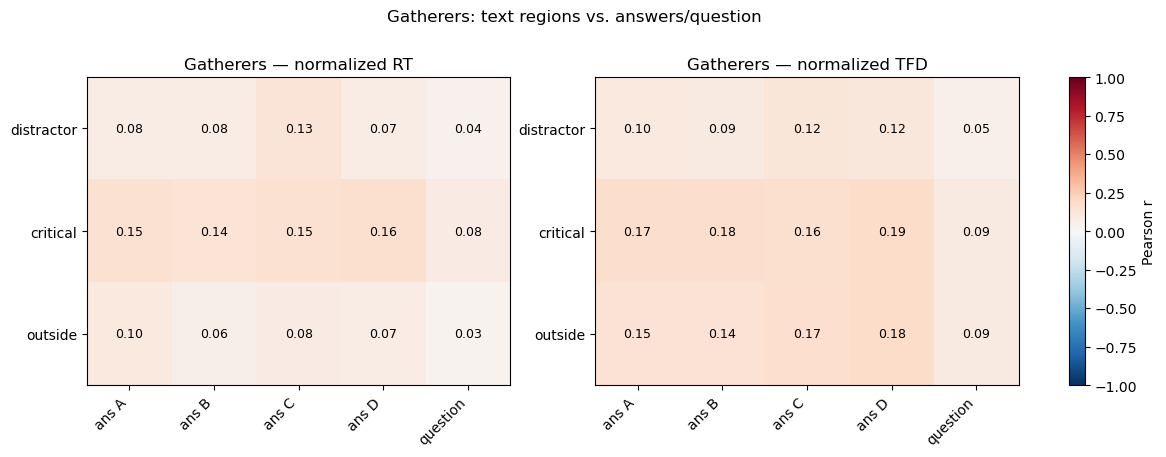

In [8]:
plot_group(group_dfs["gatherers"], "Gatherers")

## Predict answer reading times from paragraph features

One regression per answer (A/B/C/D). Predictors are paragraph-only: per-span area
metrics, per-span RT/TFD (pure + normalized), and the hunter/gatherer preview
flag — no answer-area features. Pick `FEATURE_COLS` to control what goes in.

In [9]:
from src.predictive_modeling.answer_RTs.model_data import (
    build_answer_rt_model_df,
    get_paragraph_feature_cols,
    get_span_area_feature_cols,
    get_span_rt_tfd_feature_cols,
    get_preview_feature_cols,
)
from src.predictive_modeling.answer_RTs.run import run_answer_rt_regression

# Trial-level frame: paragraph predictors + answer-RT targets (built once).
answer_rt_model_df = build_answer_rt_model_df()
print("model df:", answer_rt_model_df.shape)


def plot_true_pred(out, answers=("A", "B", "C", "D")):
    """2x2 held-out true-vs-predicted scatter, coloured by reading regime."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    target = out["results"][answers[0]]["metrics"]["target"].rsplit("_answer_", 1)[0]
    for ax, ans in zip(axes.ravel(), answers):
        res = out["results"][ans]
        p, m = res["predictions"], res["metrics"]
        if "question_preview" in p.columns:
            for val, lab, c in [(1, "hunter", "tab:orange"), (0, "gatherer", "tab:blue")]:
                s = p[p["question_preview"] == val]
                ax.scatter(s["y_true"], s["y_pred"], s=6, alpha=0.3, color=c, label=lab)
            ax.legend(fontsize=8)
        else:
            ax.scatter(p["y_true"], p["y_pred"], s=6, alpha=0.3)
        lo = float(min(p["y_true"].min(), p["y_pred"].min()))
        hi = float(max(p["y_true"].max(), p["y_pred"].max()))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"answer {ans}:  R²={m['r2']:.3f}   RMSE={m['rmse']:.0f}")
        ax.set_xlabel("true RT")
        ax.set_ylabel("predicted RT")
    fig.suptitle(f"True vs predicted — {target}", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_coefs(out, answers=("A", "B", "C", "D"), top_k=12):
    """2x2 top-|coef| standardized coefficients per answer (features are z-scored)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, ans in zip(axes.ravel(), answers):
        cs = out["results"][ans]["coef_summary"].head(top_k).iloc[::-1]
        colors = ["tab:red" if v < 0 else "tab:green" for v in cs["coef"]]
        ax.barh(cs["feature"], cs["coef"], color=colors)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_title(f"answer {ans} — top {top_k} |coef|")
        ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()


# --- choose which features to run -------------------------------------------
FEATURE_COLS = get_paragraph_feature_cols(answer_rt_model_df)   # everything (default)
# FEATURE_COLS = get_span_rt_tfd_feature_cols(answer_rt_model_df) + get_preview_feature_cols(answer_rt_model_df)
# FEATURE_COLS = get_span_area_feature_cols(answer_rt_model_df)
print("n features chosen:", len(FEATURE_COLS))

model df: (19436, 53)
n features chosen: 43


answer A: R2=0.022 RMSE=352.715 (baseline 356.835) MAE=192.952  [n_train=15549, n_test=3887]
answer B: R2=0.035 RMSE=262.232 (baseline 267.118) MAE=147.923  [n_train=15549, n_test=3887]
answer C: R2=0.052 RMSE=224.603 (baseline 230.700) MAE=124.194  [n_train=15549, n_test=3887]
answer D: R2=0.027 RMSE=210.431 (baseline 213.318) MAE=117.881  [n_train=15549, n_test=3887]


,answer,target,n_train,n_test,n_features,r2,rmse,mae,baseline_rmse
0,A,RT_normalized_answer_A,15549,3887,43,0.022,352.715,192.952,356.835
1,B,RT_normalized_answer_B,15549,3887,43,0.035,262.232,147.923,267.118
2,C,RT_normalized_answer_C,15549,3887,43,0.052,224.603,124.194,230.700
3,D,RT_normalized_answer_D,15549,3887,43,0.027,210.431,117.881,213.318


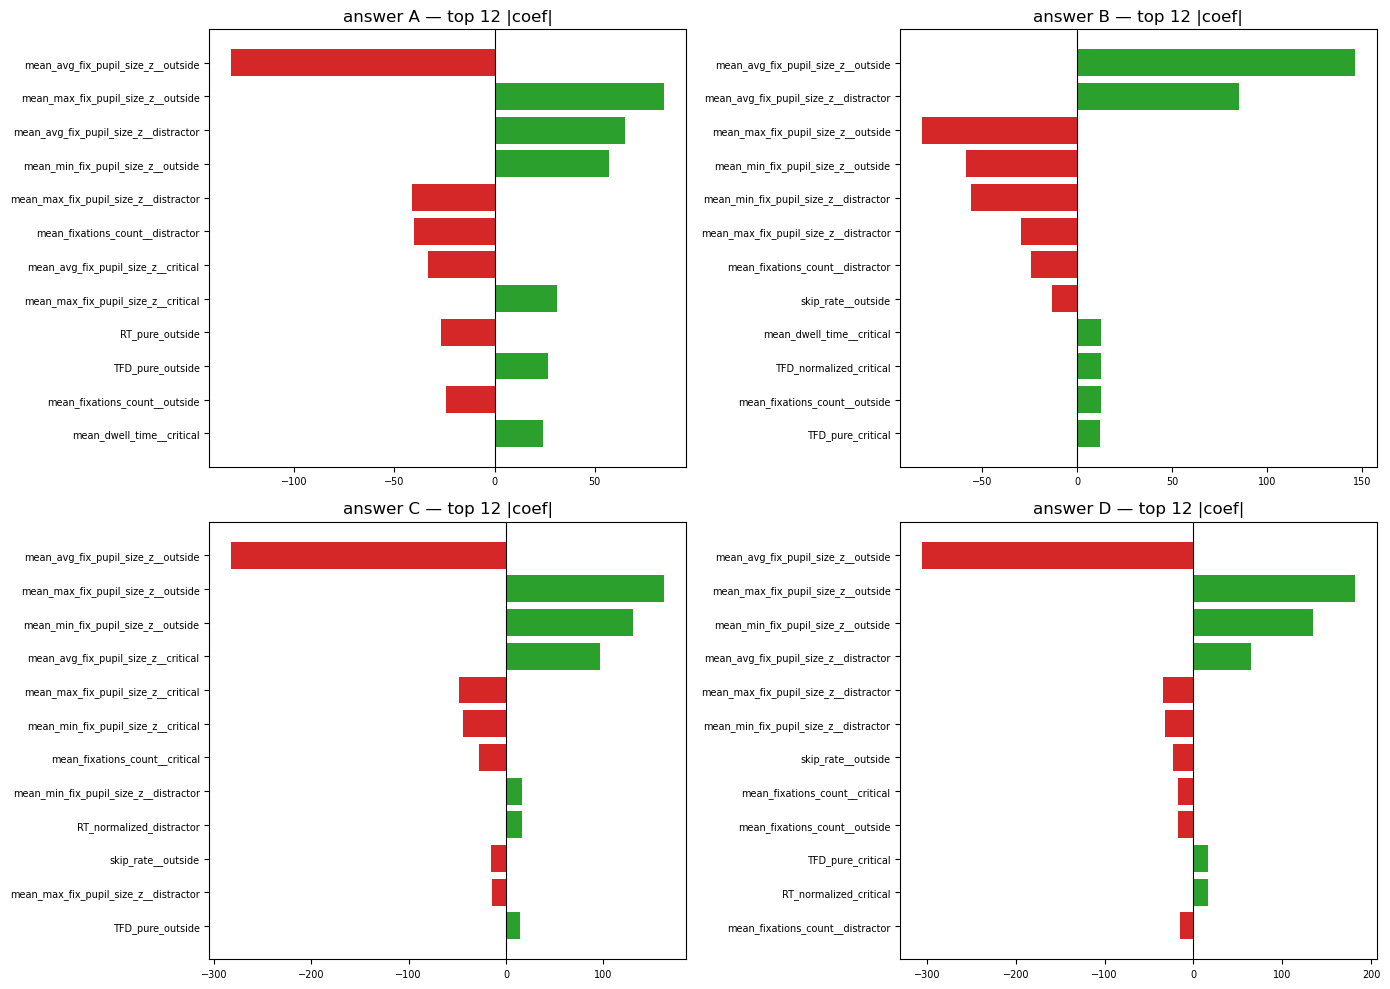

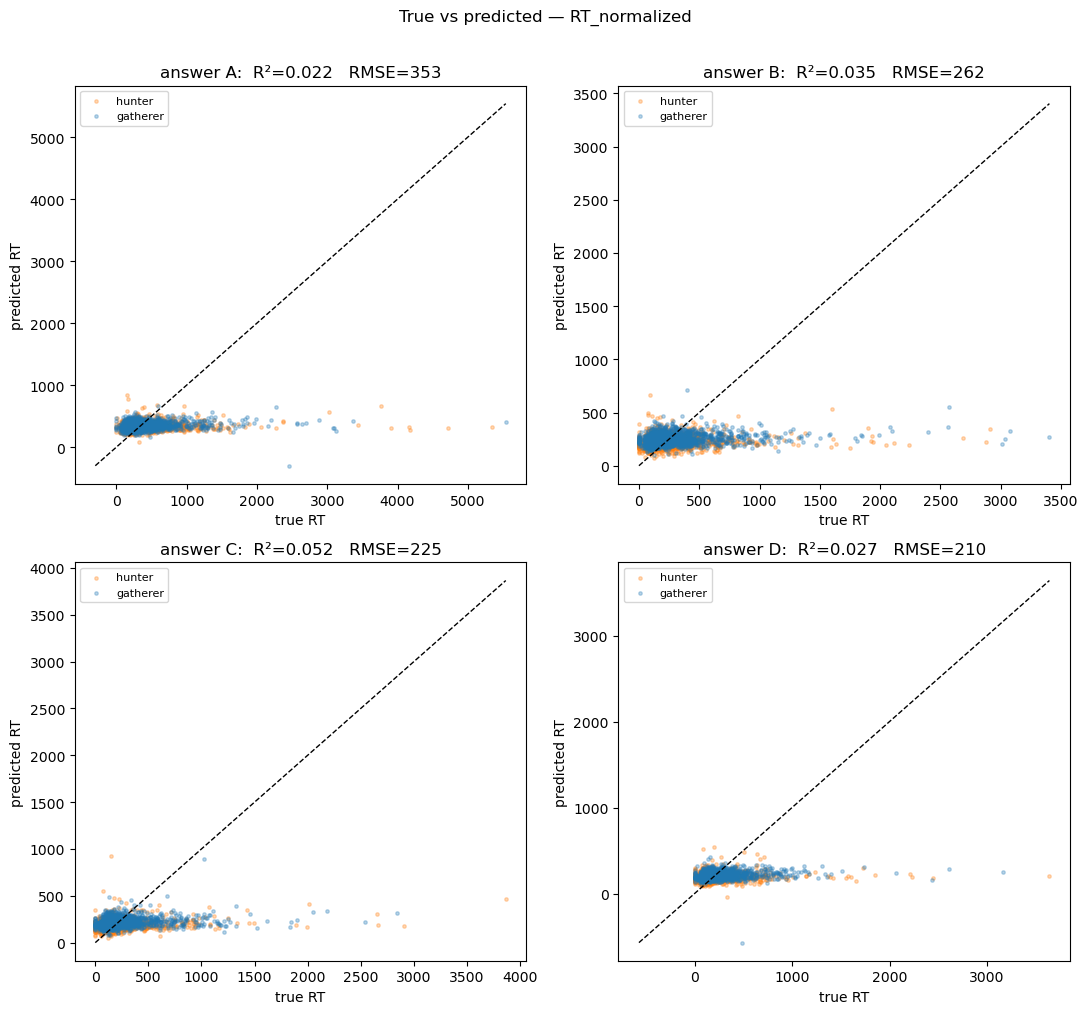

: 

In [ ]:
out_answer_rt = run_answer_rt_regression(
    model_df=answer_rt_model_df,
    feature_cols=FEATURE_COLS,
    rt_metric="RT_normalized",   # target: RT_normalized_answer_{A..D} ("RT_pure" also available)
    model_kind="ridge",          # "ridge" or "linear"
    alpha=1.0,
    test_size=0.2,
    random_state=42,
)

# per-answer held-out metrics
display(out_answer_rt["metrics"].round(3))

# coefficients and true/predicted
plot_coefs(out_answer_rt)
plot_true_pred(out_answer_rt)

## Trial-level paragraph reading features (lab's external extraction)

Runs the feature extraction taken from the lab's EyeBench / OneStop pipeline
(vendored in `src/external/EyeBench/`, constants in
`src/external/EyeBench/configs/constants.py`) on our paragraph reports, via the
adapter `src/external/EyeBench/paragraph_trial_features.py` — which also reproduces
their `OneStopProcessor` preprocessing step-for-step, since our reports are raw
where theirs are already processed.

One row per (`participant_id`, `TRIAL_INDEX`) trial, **1275 columns** with `RECONSTRUCT`
on (1240 without), each tagged by model family in the two
`*_trial_level_feature_keys.csv` files written alongside:

| family | n | what |
| --- | --- | --- |
| `RF` | 546 | every column of `numerical_ia_trial_columns` / `numerical_fixation_trial_columns` × 7 aggregations (mean/std/median/skew/kurtosis/max/min), prefixed `ia_feature_` / `fix_feature_` |
| `BEYELSTM` | 676 | gaze entropy (`fixation_feature_SGE` / `GTE`), fixation & word counts, and the 16 `gsf_features` averaged per word category → `<category>_<value>_<feature>` (`is_content_word`, `ptb_pos` = reduced POS `0.0`–`4.0` = FUNC/NOUN/VERB/ADJ/UNKNOWN, `entity_type`, `universal_pos`) |
| `SVM` | 9 | `skip_rate`, `num_of_fixations`, `mean_TFD`, `NEXT_SAC_*_mean/max` |
| `LOGISTIC` | 9 | `first_pass_skip_rate`, `mean_FFD/GD/TFD`, `mean_go_past_time`, `CURRENT_FIX_DURATION_mean`, `forward_saccade_length_mean`, `regression_rate` |
| `READING_SPEED` | 1 | `reading_speed` — words per **ms** (`PARAGRAPH_RT` is in ms) |

Practice and repeated-reading trials are dropped (as in `split_hunters_and_gatherers`);
`question_preview` (hunter = 1 / gatherer = 0) is attached for splitting later.

Three things to know before modelling:

- **~145 columns are constant zero.** Degenerate aggregations (`min` of count columns,
  spread of trial-constant columns like `PARAGRAPH_RT`), plus **all 80 `ptb_pos_*`
  columns** — in the source pipeline `ptb_pos` is mapped to numbers by
  `add_missing_features` and then mapped again per trial, yielding all-NaN and an
  empty grouping. `FIX_PTB_POS = True` gives them real values (function words 311 ms
  mean dwell vs. nouns 448).
- **23 of the `RECONSTRUCT` columns are exact duplicates** of features that already
  exist under our own column names (`ia_feature_*_landing_position` ==
  `ia_feature_*_IA_FIRST_RUN_LANDING_POSITION`, and likewise for
  `IA_FIRST_FIX_DURATION` / `IA_TOTAL_FIXATION_DURATION`). The 12 genuinely new ones
  are per-word saccade duration and peak velocity, aggregated from the fixation report.
- Words with no named entity are dropped from the `entity_type` grouping rather than
  forming a `NONE` category, as in the source.

The full build reads two multi-GB reports and takes ~1.5 h, so the result is cached at
`PARAGRAPH_TRIAL_FEATURES_PATH`. Use `QUICK_TEST` for a fast smoke run first.

In [4]:
from src.data_paths import (
    PARAGRAPH_TRIAL_FEATURES_DIR,
    PARAGRAPH_TRIAL_FEATURES_PATH,
)
from src.external.EyeBench.paragraph_trial_features import (
    build_paragraph_trial_level_features,
    load_paragraph_trial_level_features,
    save_paragraph_trial_level_features,
)

REBUILD = False   # True -> re-run the extraction even if the CSV already exists
QUICK_TEST = 2    # >0 -> only that many participants (a fast smoke run, not saved)
WITH_FIXATIONS = True  # False -> IA-only features (much faster, drops the fix_/gsf ones)

# False reproduces the source pipeline exactly, where the 80 ptb_pos_* columns come
# out all-zero because ptb_pos is mapped to numbers twice. True gives them real
# values. Nothing else differs between the two.
FIX_PTB_POS = True

# Fill IA columns their feature list wants but our report names differently or
# lacks (see reconstruct_source_columns): +35 columns, of which 23 duplicate
# existing ones exactly and 12 are new (per-word saccade duration / velocity).
RECONSTRUCT = True

build_kwargs = dict(
    include_fixation_features=WITH_FIXATIONS,
    fix_ptb_pos_double_mapping=FIX_PTB_POS,
    reconstruct_missing_columns=RECONSTRUCT,
)

if QUICK_TEST:
    participants = sorted(pd.read_csv(READY_ALL_FEATURES_PATH, usecols=["participant_id"])
                          ["participant_id"].unique())[:QUICK_TEST]
    trial_features = build_paragraph_trial_level_features(
        participants=participants, **build_kwargs
    )
elif REBUILD or not PARAGRAPH_TRIAL_FEATURES_PATH.exists():
    trial_features = save_paragraph_trial_level_features(**build_kwargs)
else:
    trial_features = load_paragraph_trial_level_features()

print("trial-level paragraph features:", trial_features.shape)

# What each feature belongs to (written by the extraction: RF / BEYELSTM / SVM /
# LOGISTIC / READING_SPEED).
feature_keys = pd.concat(
    [
        pd.read_csv(PARAGRAPH_TRIAL_FEATURES_DIR / name).assign(source=name.split("_")[0])
        for name in ("ia_trial_level_feature_keys.csv", "fixation_trial_level_feature_keys.csv")
        if (PARAGRAPH_TRIAL_FEATURES_DIR / name).exists()
    ],
    ignore_index=True,
)
display(feature_keys.groupby(["source", "feature_type"]).size().rename("n_features"))

trial_features.head()

Reading ia_Paragraph.csv ...
  IA rows: 11,472 | trials: 108
Reading fixations_Paragraph.csv (this one is big) ...
  fixation rows: 13,652 | trials: 108
Preparing IA data ...
Preparing fixation data ...


2026-08-03 15:34:41.849 | INFO     | external_paragraph_feature_extraction:compute_trial_level_features:677 - Computing trial level features for 11472 trials with [('is_content_word', [np.int64(0), np.int64(1)]), ('ptb_pos', [np.float64(0.0), np.float64(2.0), np.float64(1.0), np.float64(3.0)]), ('entity_type', [nan, 'PERSON', 'CARDINAL', 'GPE', 'DATE', 'ORG', 'MONEY', 'NORP', 'QUANTITY', 'TIME', 'LOC', 'PERCENT', 'ORDINAL', 'PRODUCT', 'EVENT', 'WORK_OF_ART', 'FAC']), ('universal_pos', ['PRON', 'VERB', 'DET', 'PROPN', 'ADP', 'NOUN', 'AUX', 'ADV', 'NUM', 'CCONJ', 'PART', 'ADJ', 'SCONJ', 'INTJ', 'PUNCT'])] groupby mappings
2026-08-03 15:34:41.850 | INFO     | external_paragraph_feature_extraction:compute_trial_level_features:684 - This might take a couple of minutes, please be patient...
2026-08-03 15:34:41.862 | INFO     | external_paragraph_feature_extraction:compute_trial_level_features:685 -  Number of trial groups in ia: 108


  reconstructed 5 source columns: IA_FIRST_FIX_DURATION <- IA_FIRST_FIXATION_DURATION; IA_TOTAL_FIXATION_DURATION <- IA_DWELL_TIME; landing_position <- IA_FIRST_RUN_LANDING_POSITION; mean_sacc_dur <- mean per-word NEXT_SAC_DURATION; peak_sacc_velocity <- mean per-word NEXT_SAC_PEAK_VELOCITY
  note: 2 IA columns absent from our reports, so 14 features are not produced: IA_FIRST_FIX_DWELL_TIME, IA_REGRESSION_OUT_TIME
Computing trial level features for 108 trials (IA + fixations) ...


2026-08-03 15:34:50.068 | INFO     | external_paragraph_feature_extraction:compute_trial_level_features:694 - Computing fixation trial level features for 13652 trials with [('is_content_word', [np.int64(0), np.int64(1)]), ('ptb_pos', [np.float64(0.0), np.float64(2.0), np.float64(1.0), np.float64(3.0)]), ('entity_type', [nan, 'PERSON', 'CARDINAL', 'GPE', 'DATE', 'ORG', 'MONEY', 'NORP', 'QUANTITY', 'TIME', 'LOC', 'PERCENT', 'ORDINAL', 'PRODUCT', 'EVENT', 'WORK_OF_ART', 'FAC']), ('universal_pos', ['PRON', 'VERB', 'DET', 'PROPN', 'ADP', 'NOUN', 'AUX', 'ADV', 'NUM', 'CCONJ', 'PART', 'ADJ', 'SCONJ', 'INTJ', 'PUNCT'])] groupby mappings
2026-08-03 15:34:50.068 | INFO     | external_paragraph_feature_extraction:compute_trial_level_features:697 - This might take a couple of minutes, please be patient...
2026-08-03 15:34:50.076 | INFO     | external_paragraph_feature_extraction:compute_trial_level_features:703 - Number of trial groups in fix: 108
2026-08-03 15:34:50.076 | INFO     | external_para

Done: 108 trials x 1195 columns
trial-level paragraph features: (108, 1195)


source    feature_type 
fixation  BEYELSTM         596
          LOGISTIC           3
          RF               322
          SVM                6
ia        LOGISTIC           6
          READING_SPEED      1
          RF               259
          SVM                3
Name: n_features, dtype: int64

fix_feature_mean_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                          
l10_202        3                                       180.557252   
               4                                       179.840659   
               6                                       164.600000   
               7                                       183.842520   
               8                                       190.385714   

                            fix_feature_std_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                         
l10_202        3                                       70.070102   
               4                                       63.160461   
               6                                       55.612567   
               7                                       62.567938   
               8                                       94.941379   

                            fix_feature_median_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                            
l10_202        3                                              175.0   
               4                                              170.0   
               6                                              162.0   
               7                                              180.0   
               8                                              174.0   

                            fix_feature_skew_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                          
l10_202        3                                         1.294693   
               4                                         1.341336   
               6                                         1.106015   
               7                                         0.330660   
               8                                         2.591273   

                            fix_feature_kurtosis_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                              
l10_202        3                                             4.544828   
               4                                             5.359139   
               6                                             2.857553   
               7                                             0.227690   
               8                                            10.070930   

                            fix_feature_max_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                         
l10_202        3                                           501.0   
               4                                           536.0   
               6                                           395.0   
               7                                           364.0   
               8                                           722.0   

                            fix_feature_min_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                         
l10_202        3                                            25.0   
               4                                            36.0   
               6                                            48.0   
               7                                            29.0   
               8                                            27.0   

                            fix_feature_mean_CURRENT_FIX_INTEREST_AREA_DWELL_TIME  \
participant_id TRIAL_INDEX                                                          
l10_202        3                                                   540.687023       
               4                                                   389.939560       
               6                                                   298.470588       
               7                                                   377.771654       
               8                                                   939.744253       

                       

In [3]:
trial_features

fix_feature_mean_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                          
l10_202        3                                       180.557252   
               4                                       179.840659   
               6                                       164.600000   
               7                                       183.842520   
               8                                       190.385714   
...                                                           ...   
l10_269        58                                      172.408163   
               59                                      184.309735   
               60                                      190.423529   
               61                                      171.545455   
               63                                      184.984848   

                            fix_feature_std_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                         
l10_202        3                                       70.070102   
               4                                       63.160461   
               6                                       55.612567   
               7                                       62.567938   
               8                                       94.941379   
...                                                          ...   
l10_269        58                                      81.336017   
               59                                      69.147793   
               60                                      66.856277   
               61                                      64.096561   
               63                                      60.611153   

                            fix_feature_median_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                            
l10_202        3                                              175.0   
               4                                              170.0   
               6                                              162.0   
               7                                              180.0   
               8                                              174.0   
...                                                             ...   
l10_269        58                                             164.0   
               59                                             181.0   
               60                                             190.5   
               61                                             166.0   
               63                                             179.0   

                            fix_feature_skew_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                          
l10_202        3                                         1.294693   
               4                                         1.341336   
               6                                         1.106015   
               7                                         0.330660   
               8                                         2.591273   
...                                                           ...   
l10_269        58                                        1.847512   
               59                                        1.780418   
               60                                        0.492010   
               61                                        0.607676   
               63                                        0.773907   

                            fix_feature_kurtosis_CURRENT_FIX_DURATION  \
participant_id TRIAL_INDEX                                              
l10_202        3                                             4.544828   
               4                                             5.359139   
               6                                             2.857553   
               7                                          